In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score

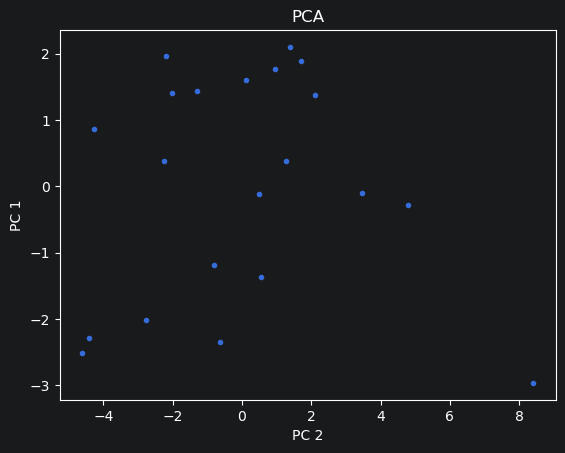

kmeans=3 Inertia:  107.77325290187218
kmeans=5 Inertia:  34.488881320019466
kmeans=7 Inertia:  14.333106976790923
kmeans=9 Inertia:  8.089229104913192


C:\Users\jorda\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jorda\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jorda\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jorda\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Wi

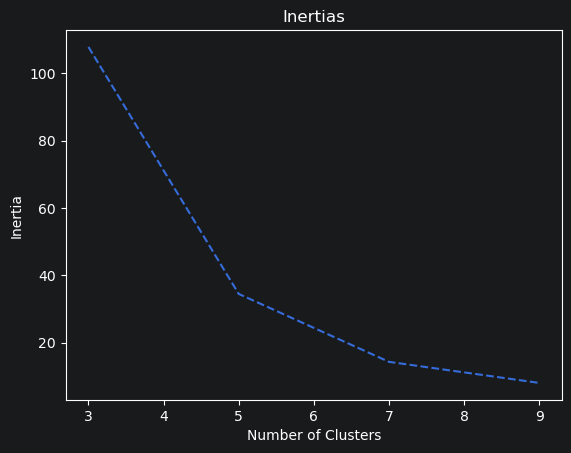

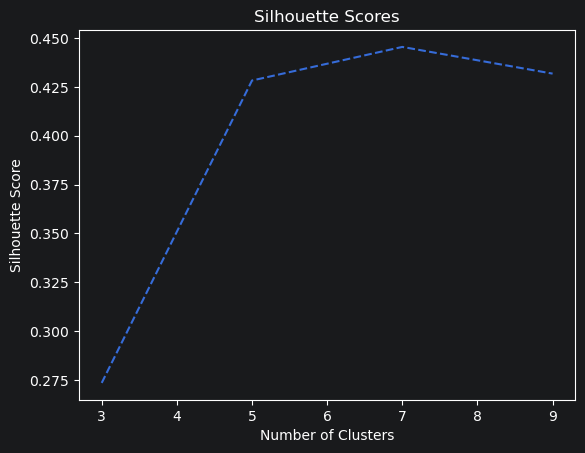

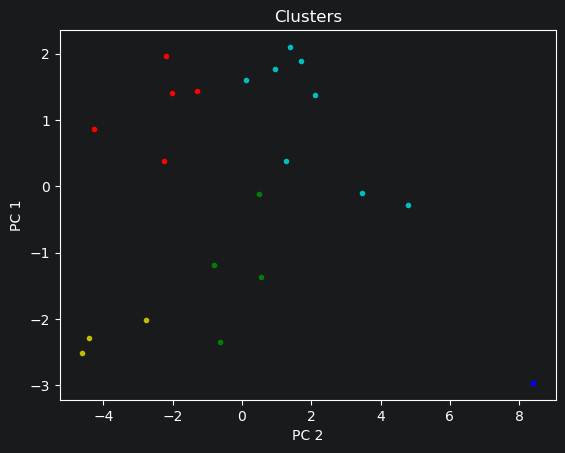

In [13]:
SEED = 42


df = pd.read_csv("Chevy_US_Data.csv")


num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder())
])


from pandas.api.types import is_numeric_dtype

numeric_features = [c for c in df.columns if is_numeric_dtype(df[c])]
categorical_features = [c for c in df.columns if c not in numeric_features]


pre = ColumnTransformer([
    ("num", num_pipe, numeric_features),
    ("cat", cat_pipe, categorical_features)
])




pca_pipe = Pipeline([
    ("pre", pre),
    ("pca", PCA(n_components=2, svd_solver="auto"))
])


pca_pipe.fit(df)

X_trans = pca_pipe.transform(df)





X = []
Y = []



for i in range(len(X_trans)):
    X.append(X_trans[i][0])
    Y.append(X_trans[i][1])



plt.figure()

plt.title("PCA")
plt.plot(X, Y, '.')
plt.xlabel("PC 2")
plt.ylabel("PC 1")
plt.show()


plt.close()



kmeans_pipe = Pipeline([
    ("kmeans", KMeans())
])



kmeans_clusters = [3, 5, 7, 9]

inertias = []


silhouettes = []


kmeans_pipe.set_params(kmeans__n_clusters=kmeans_clusters[0])



kmeans_pipe.fit(X_trans)


labels_3 = kmeans_pipe.predict(X_trans)


inertias.append(kmeans_pipe.get_params(deep=True)["kmeans"].inertia_)

silhouettes.append(silhouette_score(X_trans, labels_3))



print("kmeans=3 Inertia: ", kmeans_pipe.get_params(deep=True)["kmeans"].inertia_)


kmeans_pipe.set_params(kmeans__n_clusters=kmeans_clusters[1])


kmeans_pipe.fit(X_trans)


labels_5 = kmeans_pipe.predict(X_trans)

inertias.append(kmeans_pipe.get_params(deep=True)["kmeans"].inertia_)

silhouettes.append(silhouette_score(X_trans, labels_5))


print("kmeans=5 Inertia: ", kmeans_pipe.get_params(deep=True)["kmeans"].inertia_)


kmeans_pipe.set_params(kmeans__n_clusters=kmeans_clusters[2])


kmeans_pipe.fit(X_trans)

labels_7 = kmeans_pipe.predict(X_trans)


inertias.append(kmeans_pipe.get_params(deep=True)["kmeans"].inertia_)


silhouettes.append(silhouette_score(X_trans, labels_7))


kmeans_pipe.set_params(kmeans__n_clusters=kmeans_clusters[3])


print("kmeans=7 Inertia: ", kmeans_pipe.get_params(deep=True)["kmeans"].inertia_)


kmeans_pipe.fit(X_trans)


labels_9 = kmeans_pipe.predict(X_trans)



inertias.append(kmeans_pipe.get_params(deep=True)["kmeans"].inertia_)


silhouettes.append(silhouette_score(X_trans, labels_9))



print("kmeans=9 Inertia: ", kmeans_pipe.get_params(deep=True)["kmeans"].inertia_)



plt.figure()

plt.title("Inertias")
plt.plot(kmeans_clusters, inertias, '--')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

plt.close()



plt.figure()

plt.title("Silhouette Scores")
plt.plot(kmeans_clusters, silhouettes, '--')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")


plt.show()


plt.close()


#I am primarily using the Silhouette Scores for the decision on the best model. I am going with k=5 since that gave the best Silhouette Score


cluster_1 = []
cluster_2 = []
cluster_3 = []
cluster_4 = []
cluster_5 = []



for i in range(len(labels_5)):
    if labels_5[i] == 0:
        cluster_1.append(X_trans[i])


    if labels_5[i] == 1:
        cluster_2.append(X_trans[i])

    if labels_5[i] == 2:
        cluster_3.append(X_trans[i])


    if labels_5[i] == 3:
        cluster_4.append(X_trans[i])


    if labels_5[i] == 4:
        cluster_5.append(X_trans[i])



X_1 = []
Y_1 = []


for i in range(len(cluster_1)):
    X_1.append(cluster_1[i][0])
    Y_1.append(cluster_1[i][1])



X_2 = []
Y_2 = []


for i in range(len(cluster_2)):
  X_2.append(cluster_2[i][0])
  Y_2.append(cluster_2[i][1])




X_3 = []
Y_3 = []



for i in range(len(cluster_3)):
  X_3.append(cluster_3[i][0])
  Y_3.append(cluster_3[i][1])


X_4 = []
Y_4 = []



for i in range(len(cluster_4)):
  X_4.append(cluster_4[i][0])
  Y_4.append(cluster_4[i][1])

X_5 = []
Y_5 = []



for i in range(len(cluster_5)):
  X_5.append(cluster_5[i][0])
  Y_5.append(cluster_5[i][1])




plt.figure()

plt.title("Clusters")
plt.plot(X_1, Y_1, 'r.')
plt.plot(X_2, Y_2, 'g.')
plt.plot(X_3, Y_3, 'b.')
plt.plot(X_4, Y_4, 'y.')
plt.plot(X_5, Y_5, 'c.')

plt.xlabel("PC 2")
plt.ylabel("PC 1")


plt.show()

plt.close()
